<IPython.core.display.Javascript object>

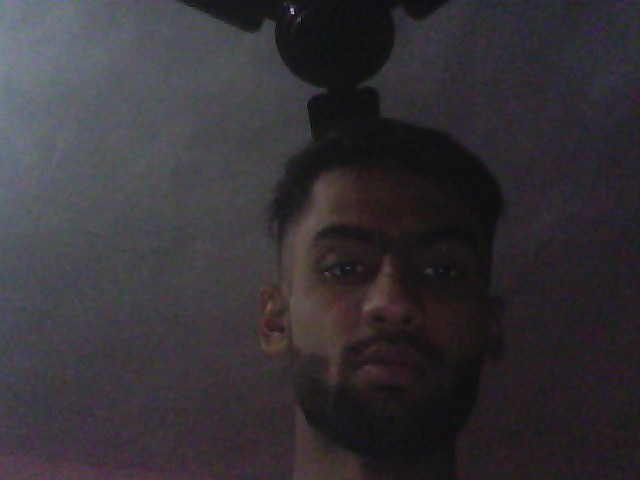

Frame captured successfully!


In [5]:
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def capture_frame():
    js = Javascript("""
    async function captureFrame() {
        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.display = 'block';
        video.width = 640;
        video.height = 480;

        const button = document.createElement('button');
        button.textContent = 'Capture Frame';
        button.style.fontSize = '20px';
        button.style.padding = '10px';
        button.style.marginTop = '10px';

        div.appendChild(video);
        div.appendChild(button);
        document.body.appendChild(div);

        // Request webcam access
        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;
        await video.play();

        // Wait until Capture button is pressed
        await new Promise((resolve) => {
            button.onclick = resolve;
        });

        // Capture current frame
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        // Stop webcam
        stream.getVideoTracks()[0].stop();

        // Remove camera UI
        div.remove();

        return canvas.toDataURL('image/jpeg', 0.9);
    }

    captureFrame();
    """)

    display(js)

    # Get image from browser
    data = eval_js("captureFrame()")

    # Convert base64 image to OpenCV image
    binary = b64decode(data.split(',')[1])

    image = np.frombuffer(binary, dtype=np.uint8)
    frame = cv2.imdecode(image, cv2.IMREAD_COLOR)

    return frame


# Capture image from webcam
frame = capture_frame()

# Check whether frame was captured
if frame is not None:

    # Display image using OpenCV-compatible Colab function
    from google.colab.patches import cv2_imshow

    cv2_imshow(frame)

    print("Frame captured successfully!")

else:
    print("Error: Failed to capture frame.")
